In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from pathlib import Path

sys.path.insert(0, str(Path('.') / 'src'))
from config import METADATA_DIR, FIGURES_DIR

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = METADATA_DIR / "classes.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


### Data Loading

In [34]:
def load_metadata(path):
    df = pd.read_csv(path)
    print(f"Loaded dataset with shape: {df.shape}")
    print("\nColumns:")
    print(df.columns)
    return df


df = load_metadata(DATA_PATH)
df.head()

Loaded dataset with shape: (80042, 9)

Columns:
Index(['filename', 'artist', 'genre', 'description', 'phash', 'width',
       'height', 'genre_count', 'subset'],
      dtype='object')


,filename,artist,genre,description,phash,width,height,genre_count,subset
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,['Abstract Expressionism'],acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,['Abstract Expressionism'],chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,['Abstract Expressionism'],gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train
3,Abstract_Expressionism/aaron-siskind_jerome-ar...,aaron siskind,['Abstract Expressionism'],jerome-arizona-1949,a5d691f85ac5e4d0,1382,1849,1,train
4,Abstract_Expressionism/aaron-siskind_kentucky-...,aaron siskind,['Abstract Expressionism'],kentucky-4-1951,880df359e6b11db1,1382,1625,1,train


### Data Cleaning

In [35]:
def clean_metadata(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    # Convert genre string representation to actual list
    if "genre" in df.columns:
        df["genre"] = df["genre"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

    # Drop missing essentials
    df = df.dropna(subset=["artist", "genre", "width", "height"])

    df = df[(df["width"] > 0) & (df["height"] > 0)]

    print(f"After cleaning: {df.shape}")
    return df

df = clean_metadata(df)

After cleaning: (80042, 9)


In [36]:
def extract_year_from_description(df):
    df = df.copy()

    def get_year(text):
        if isinstance(text, str) and len(text) >= 5:
            fifth_last = text[-5]
            last_four = text[-4:]
            if last_four.isdigit() and fifth_last == "-":
                return int(last_four)
        return np.nan

    df["year"] = df["description"].apply(get_year)

    return df


df = extract_year_from_description(df)
df.head()

,filename,artist,genre,description,phash,width,height,genre_count,subset,year
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,[Abstract Expressionism],acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train,1955.0
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,[Abstract Expressionism],chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train,1961.0
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,[Abstract Expressionism],gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train,1944.0
3,Abstract_Expressionism/aaron-siskind_jerome-ar...,aaron siskind,[Abstract Expressionism],jerome-arizona-1949,a5d691f85ac5e4d0,1382,1849,1,train,1949.0
4,Abstract_Expressionism/aaron-siskind_kentucky-...,aaron siskind,[Abstract Expressionism],kentucky-4-1951,880df359e6b11db1,1382,1625,1,train,1951.0


Artist count summary:
Mean: 71.53
Median: 29.00
Max: 1888
Min: 1


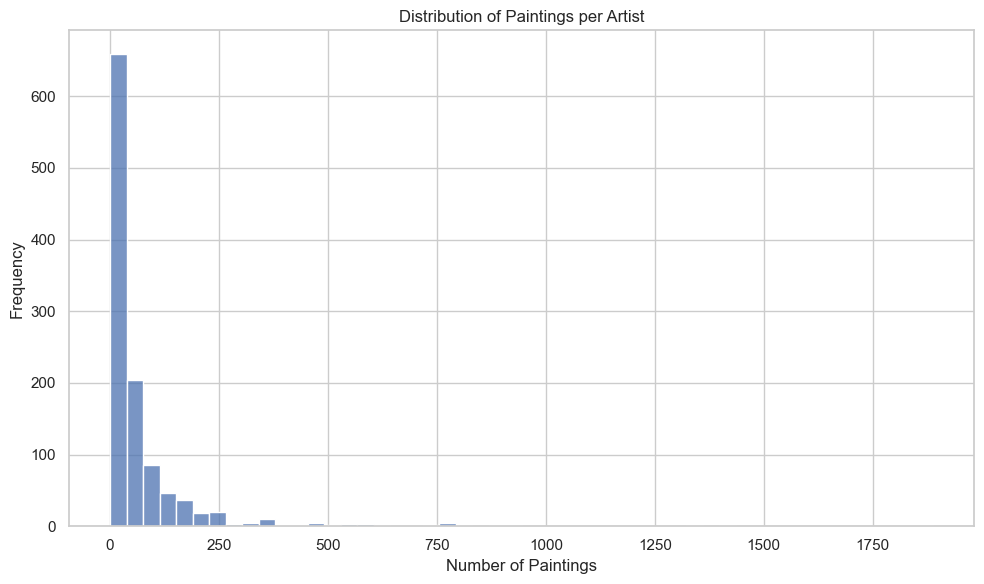

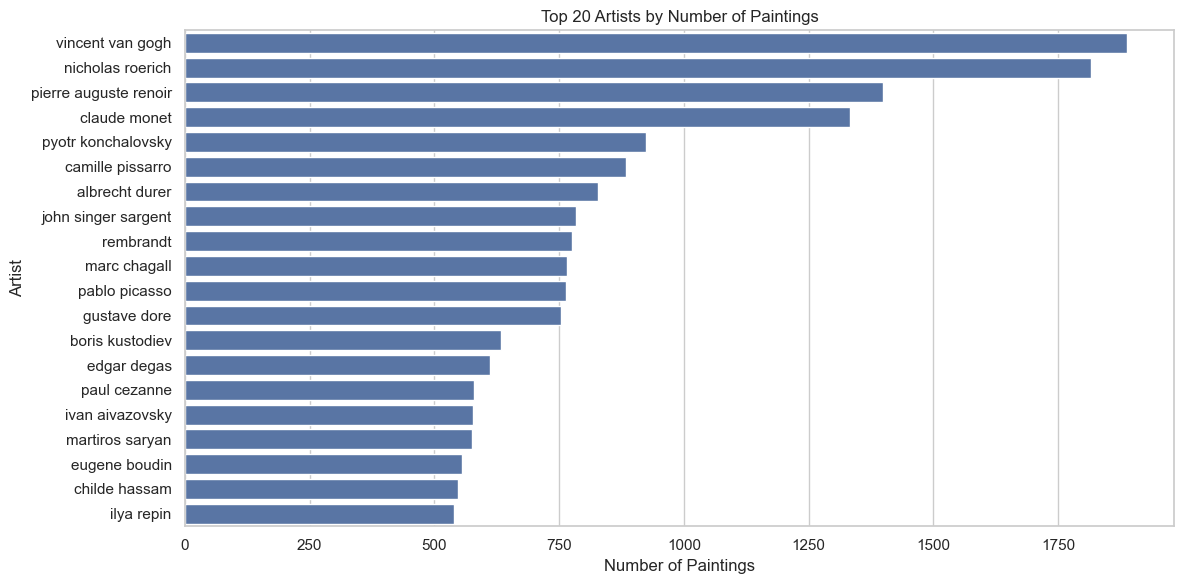

In [37]:
def analyze_artist_distribution(df):

    artist_counts = df["artist"].value_counts()

    print("Artist count summary:")
    print(f"Mean: {artist_counts.mean():.2f}")
    print(f"Median: {artist_counts.median():.2f}")
    print(f"Max: {artist_counts.max()}")
    print(f"Min: {artist_counts.min()}")

    # Histogram
    plt.figure()
    sns.histplot(artist_counts, bins=50)
    plt.title("Distribution of Paintings per Artist")
    plt.xlabel("Number of Paintings")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "paintings_per_artist_histogram.png")
    plt.show()

    # Top 20 artists
    top20 = artist_counts.head(20)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top20.values, y=top20.index)
    plt.title("Top 20 Artists by Number of Paintings")
    plt.xlabel("Number of Paintings")
    plt.ylabel("Artist")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "top20_artists.png")
    plt.show()


analyze_artist_distribution(df)


Year statistics:
count    43106.000000
mean      1869.733146
std        120.927953
min       1401.000000
25%       1874.000000
50%       1903.000000
75%       1930.000000
max       2012.000000
Name: year, dtype: float64


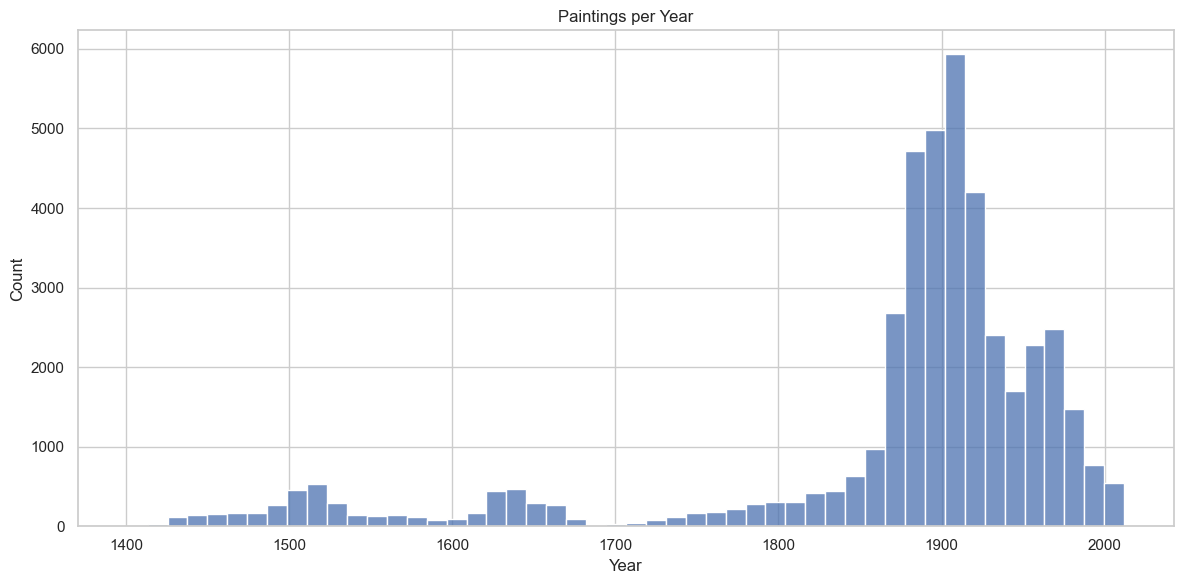


Year statistics:
count       4.000000
mean     1292.250000
std       105.338739
min      1148.000000
25%      1247.000000
50%      1322.000000
75%      1367.250000
max      1377.000000
Name: year, dtype: float64

Paintings from 1000-1400
                                                filename    year
30953  Mannerism_Late_Renaissance/giorgio-vasari_cath...  1377.0
36446  Northern_Renaissance/jean-fouquet_the-arrival-...  1364.0
47653         Realism/james-tissot_statesmen-no-1280.jpg  1280.0
73125  Northern_Renaissance/jean-fouquet_crusaders-ar...  1148.0


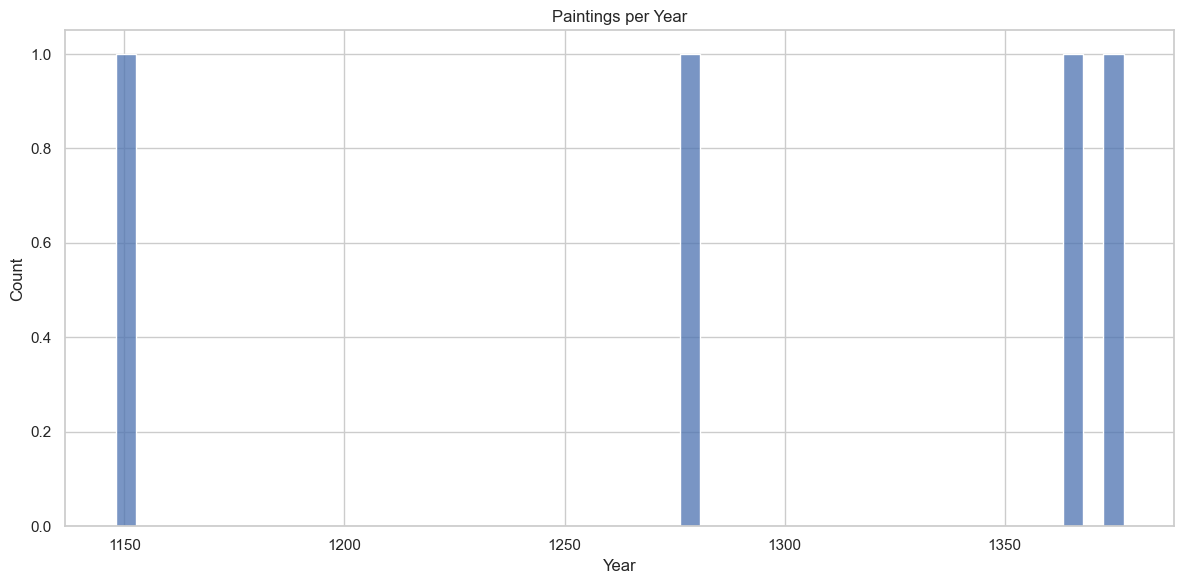

In [38]:
def analyze_era_distribution(df):

    if "year" in df.columns:

        year_df = df.dropna(subset=["year"])
        year_df1 = year_df[(year_df["year"] >= 1400) & (year_df["year"] <= 2025)]
        year_df2 = year_df[(year_df["year"] >= 1000) & (year_df["year"] <= 1400)]


        if len(year_df1) > 0:

            print("\nYear statistics:")
            print(year_df1["year"].describe())

            plt.figure(figsize=(12, 6))
            sns.histplot(year_df1["year"], bins=50)
            plt.title("Paintings per Year")
            plt.xlabel("Year")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "paintings_per_year_histogram1.png")
            plt.show()

        else:
            print("\nYear column exists but contains only NaN values.")

        if len(year_df2) > 0:

            print("\nYear statistics:")
            print(year_df2["year"].describe())

            print("\nPaintings from 1000-1400")
            print(year_df2[["filename","year"]])

            plt.figure(figsize=(12, 6))
            sns.histplot(year_df2["year"], bins=50)
            plt.title("Paintings per Year")
            plt.xlabel("Year")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "paintings_per_year_histogram2.png")
            plt.show()

        else:
            print("\nYear column exists but contains only NaN values.")

    else:
        print("\nNo 'year' column found.")

analyze_era_distribution(df)

In [39]:
print("Min year:", df["year"].min())
print("Max year:", df["year"].max())

print("\nSuspicious years:")
print(df[(df["year"] > 2026)]["year"].unique())

Min year: 1148.0
Max year: 5533.0

Suspicious years:
[5533.]


In [40]:
df_exploded = df.explode("genre")
df_exploded

,filename,artist,genre,description,phash,width,height,genre_count,subset,year
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,Abstract Expressionism,acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train,1955.0
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,Abstract Expressionism,chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train,1961.0
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,Abstract Expressionism,gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train,1944.0
3,Abstract_Expressionism/aaron-siskind_jerome-ar...,aaron siskind,Abstract Expressionism,jerome-arizona-1949,a5d691f85ac5e4d0,1382,1849,1,train,1949.0
4,Abstract_Expressionism/aaron-siskind_kentucky-...,aaron siskind,Abstract Expressionism,kentucky-4-1951,880df359e6b11db1,1382,1625,1,train,1951.0
...,...,...,...,...,...,...,...,...,...,...
80037,Impressionism/edgar-degas_portrait-of-mary-cas...,edgar degas,Impressionism,portrait-of-mary-cassatt,fc8d8c9c49e15365,1382,1756,1,uncertain artist,NaN
80038,High_Renaissance/giorgione_portrait-of-a-venet...,giorgione,High Renaissance,portrait-of-a-venetian-gentleman-1510(2),fcfc9b330325708c,1382,1645,1,uncertain artist,NaN
80039,High_Renaissance/titian_portrait-of-a-venetian...,titian,High Renaissance,portrait-of-a-venetian-nobleman(1),fcfc9b330325708c,1382,1645,1,uncertain artist,NaN
80040,High_Renaissance/pinturicchio_riconciliazione-...,pinturicchio,High Renaissance,riconciliazione-di-coriolano-1509,fef3438ca0d605e1,1382,1412,1,uncertain artist,1509.0


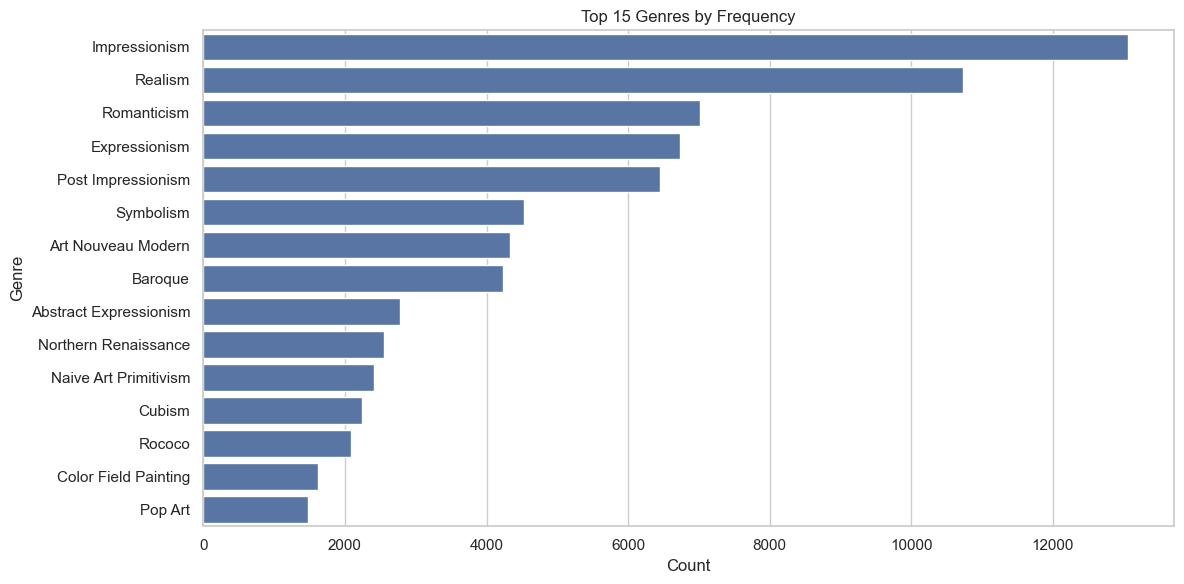

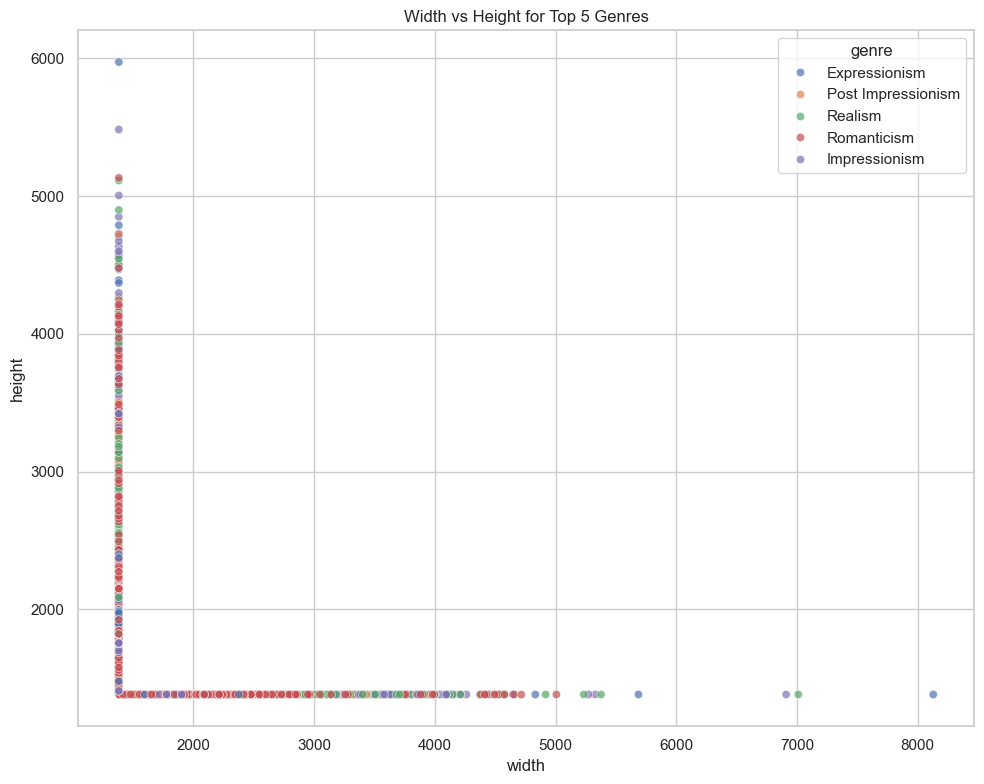

In [41]:
# Decade column and genre-based visualizations

# Add 'decade' column for valid years between 1400 and 2026
valid_years = df_exploded["year"].between(1400, 2026)

df_exploded.loc[valid_years, "decade"] = (
    df_exploded.loc[valid_years, "year"] // 10
) * 10

# Top 15 genres by frequency
top_genres = df_exploded["genre"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    orient="h",
)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Top 15 Genres by Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_genres.png")
plt.show()

# Scatterplot of width vs height for top 5 genres
top_5_genres = top_genres.head(5).index
scatter_data = df_exploded[df_exploded["genre"].isin(top_5_genres)]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=scatter_data,
    x="width",
    y="height",
    hue="genre",
    alpha=0.7,
)
plt.title("Width vs Height for Top 5 Genres")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "width_vs_height_scatter.png")
plt.show()

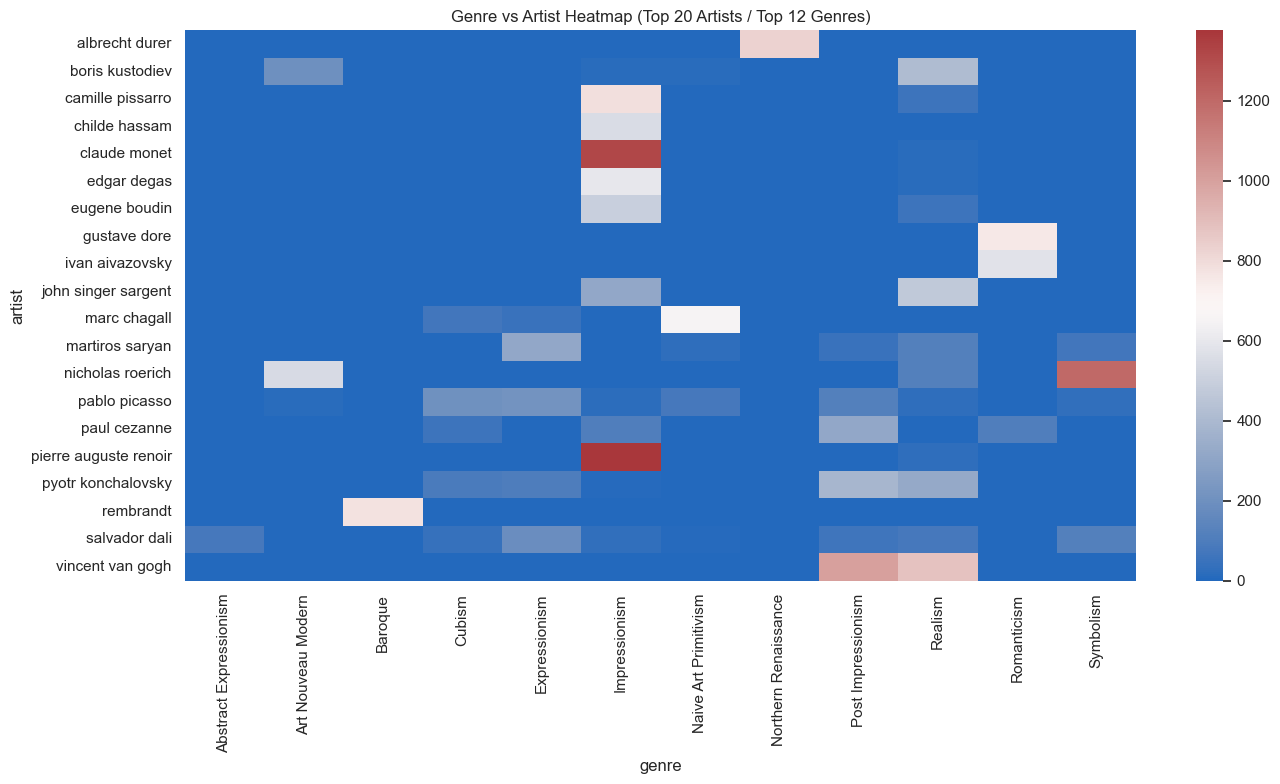

In [45]:
def genre_artist_heatmap(df):

    # Top 20 artists
    top_artists = df["artist"].value_counts().head(20).index

    # Top 15 genres
    top_genres = df["genre"].value_counts().head(20).index

    subset = df[
        (df["artist"].isin(top_artists)) &
        (df["genre"].isin(top_genres))
    ]

    pivot = pd.pivot_table(
    subset,
    index="artist",
    columns="genre",
    aggfunc="size",
    fill_value=0
)

    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, cmap="vlag")
    plt.title("Genre vs Artist Heatmap (Top 20 Artists / Top 12 Genres)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "genre_artist_heatmap.png")
    plt.show()


genre_artist_heatmap(df_exploded)

In [46]:
# def analyze_resolution(df):

#     # Aspect ratio
#     df["aspect_ratio"] = df["width"] / df["height"]

#     print("Resolution stats:")
#     print("Width - min:", df["width"].min(), 
#           "max:", df["width"].max(), 
#           "mean:", df["width"].mean())

#     print("Height - min:", df["height"].min(), 
#           "max:", df["height"].max(), 
#           "mean:", df["height"].mean())

#     print("Aspect Ratio - min:", df["aspect_ratio"].min(), 
#           "max:", df["aspect_ratio"].max(), 
#           "mean:", df["aspect_ratio"].mean())

#     # Width histogram
#     plt.figure()
#     sns.histplot(df["width"], bins=20)
#     plt.title("Width Distribution")
#     plt.tight_layout()
#     plt.savefig(FIGURES_DIR / "width_distribution.png")
#     plt.show()

#     # Height histogram
#     plt.figure()
#     sns.histplot(df["height"], bins=20)
#     plt.title("Height Distribution")
#     plt.tight_layout()
#     plt.savefig(FIGURES_DIR / "height_distribution.png")
#     plt.show()

#     # Aspect ratio histogram
#     plt.figure()
#     sns.histplot(df["aspect_ratio"], bins=20)
#     plt.title("Aspect Ratio Distribution")
#     plt.tight_layout()
#     plt.savefig(FIGURES_DIR / "aspect_ratio_distribution.png")
#     plt.show()


# analyze_resolution(df)